In [1]:
import pandas as pd
import numpy as np
import os 
from pathlib import Path

%matplotlib inline

import matplotlib.pyplot as plt

import seaborn as sn

In [2]:
attn_models = list(Path('../attn_cue_models/').glob("*"))
ctrl_models = list(Path('../multi_talker_control').glob("*"))

In [3]:
attn_models.remove(attn_models[0])
attn_models.remove(attn_models[1])
attn_models

[PosixPath('../attn_cue_models/attn_check_snr_ranges'),
 PosixPath('../attn_cue_models/attn_cue_jsin_pilot_no_pretrain_norm_at_input_pos_slope_bs_64_lr_1e-4')]

In [4]:
ctrl_models.remove(ctrl_models[0])
ctrl_models

[PosixPath('../multi_talker_control/jsin_precombined_gammatone_40_channels_20kHz_on_gpu_1e-4lr')]

In [6]:
# list(models[0].rglob("*.csv"))

In [7]:
# Get csvs of results for each model 

csv_str = 'metrics.csv'
models = [attn_models[0], ctrl_models[0]]

dfs = []
for model in models:
    # get test csvs
    results_csvs = model.rglob("*.csv")
    
    for csv in results_csvs:
        if not ("RoveRMS" in str(csv)):
            #print(csv)
            df = pd.read_csv(csv)
    #       print(model)

            test_parts = csv.as_posix().split(model.stem)[-1].split('/')[1].split('_')
    #       print(test_parts)
            df['model'] = test_parts[0]
    #       print(test_parts)
            df['snr_condition'] = test_parts[-1]
            df['version'] = csv.as_posix().split(model.stem)[-1].split('/')[2]
            dfs.append(df)
        
#         if 'Test' in path.as_posix()
results = pd.concat(dfs, axis=0, ignore_index=True)
results.drop('ACC/test_fg_acc_epoch', axis=1, inplace=True)
results.drop('ACC/test_bg_acc_epoch', axis=1, inplace=True)
results.drop('epoch', axis=1, inplace=True)

In [8]:
test_parts

['AttnTrackingControl', 'neutral']

In [9]:
attn_cueing = results[results['version'] == 'version_2']
attn_cueing

,ACC/test_fg_acc_step,ACC/test_bg_acc_step,step,model,snr_condition,version
16502,1.0,1.0,0,AttnCNN,high,version_2
16503,1.0,1.0,1,AttnCNN,high,version_2
16504,0.0,1.0,2,AttnCNN,high,version_2
16505,1.0,0.0,3,AttnCNN,high,version_2
16506,1.0,0.0,4,AttnCNN,high,version_2
...,...,...,...,...,...,...
89885,1.0,1.0,13235,AttnCNN,neutral,version_2
89886,1.0,1.0,13236,AttnCNN,neutral,version_2
89887,1.0,1.0,13237,AttnCNN,neutral,version_2
89888,0.0,1.0,13238,AttnCNN,neutral,version_2


In [10]:
control_no_cueing = results[results['model'] == 'AttnTrackingControl']
control_no_cueing = control_no_cueing[control_no_cueing['version'] == 'version_0']
control_no_cueing

,ACC/test_fg_acc_step,ACC/test_bg_acc_step,step,model,snr_condition,version
89890,0.0,1.0,0,AttnTrackingControl,high,version_0
89891,1.0,0.0,1,AttnTrackingControl,high,version_0
89892,1.0,0.0,2,AttnTrackingControl,high,version_0
89893,1.0,0.0,3,AttnTrackingControl,high,version_0
89894,1.0,0.0,4,AttnTrackingControl,high,version_0
...,...,...,...,...,...,...
140324,1.0,0.0,16808,AttnTrackingControl,neutral,version_0
140325,0.0,0.0,16809,AttnTrackingControl,neutral,version_0
140326,1.0,0.0,16810,AttnTrackingControl,neutral,version_0
140327,0.0,0.0,16811,AttnTrackingControl,neutral,version_0


In [11]:
# # filter for most recent results 
# in here we filter above into two groups and then concatenate
filtered_results = pd.concat([control_no_cueing, attn_cueing], ignore_index=True)

In [12]:
shape = filtered_results.shape

#verify proper versions are being used
mod_arr = []
ver_arr = []

for index, row in filtered_results.iterrows():
    if not(row['model'] in mod_arr) or not(row['version'] in ver_arr):
        mod_arr.append(row['model'])
        ver_arr.append(row['version'])
        
print(mod_arr)
print(ver_arr)
    

['AttnTrackingControl', 'AttnCNN']
['version_0', 'version_2']


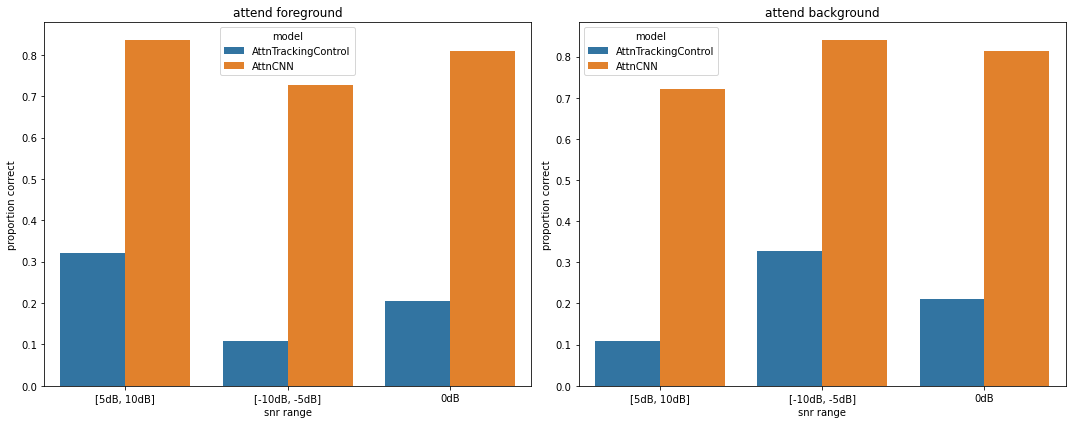

In [13]:
fig, axs = plt.subplots (1, 2, figsize=(15, 6))


g = sn.barplot(
    data=filtered_results, x='snr_condition',y='ACC/test_fg_acc_step', hue='model',
    ci=None, seed=1, ax=axs[0]
)
axs[0].set(xlabel="snr range", ylabel='proportion correct', title='attend foreground')
g.set_xticklabels(['[5dB, 10dB]', '[-10dB, -5dB]', '0dB'])

h = sn.barplot(
    data=filtered_results, x='snr_condition',y='ACC/test_bg_acc_step', hue='model',
    ci=None, seed=1, ax=axs[1]
)
axs[1].set(xlabel="snr range", ylabel='proportion correct', title='attend background')
h.set_xticklabels(['[5dB, 10dB]', '[-10dB, -5dB]', '0dB'])

plt.tight_layout()

## Checking effect of RMS level on model performance

In [14]:
rove_rms_models = list(Path('../attn_cue_models/attn_cue_jsin_pilot_no_pretrain_bs_64_lr_1e-4').glob("*RoveRMS*/*/*.csv"))
rove_rms_models

[PosixPath('../attn_cue_models/attn_cue_jsin_pilot_no_pretrain_bs_64_lr_1e-4/AttnRoveRMSCNN_high/version_1/metrics.csv'),
 PosixPath('../attn_cue_models/attn_cue_jsin_pilot_no_pretrain_bs_64_lr_1e-4/AttnRoveRMSCNN_low/version_1/metrics.csv'),
 PosixPath('../attn_cue_models/attn_cue_jsin_pilot_no_pretrain_bs_64_lr_1e-4/AttnRoveRMSCNN_neutral/version_1/metrics.csv')]

In [15]:
rove_dfs = []
for csv in rove_rms_models:
    #print(csv)
    df = pd.read_csv(csv)
    #       print(model)
#     print(df)

    test_parts = csv.as_posix().split(model.stem)[-1].split('/')
    print(test_parts)
    df['model'] = csv.as_posix().split(model.stem)[-1].split('/')[3].split('_')[0]
    #       print(test_parts)
    df['snr_condition'] = csv.as_posix().split(model.stem)[-1].split('/')[3].split('_')[1]
    df['version'] = csv.as_posix().split(model.stem)[-1].split('/')[4]
    rove_dfs.append(df)
        
#         if 'Test' in path.as_posix()
rms_results = pd.concat(rove_dfs, axis=0, ignore_index=True)
rms_results

['..', 'attn_cue_models', 'attn_cue_jsin_pilot_no_pretrain_bs_64_lr_1e-4', 'AttnRoveRMSCNN_high', 'version_1', 'metrics.csv']
['..', 'attn_cue_models', 'attn_cue_jsin_pilot_no_pretrain_bs_64_lr_1e-4', 'AttnRoveRMSCNN_low', 'version_1', 'metrics.csv']
['..', 'attn_cue_models', 'attn_cue_jsin_pilot_no_pretrain_bs_64_lr_1e-4', 'AttnRoveRMSCNN_neutral', 'version_1', 'metrics.csv']


,ACC/test_fg_acc,fg_confusion,ACC/test_bg_acc,bg_confusion,step,model,snr_condition,version
0,1.0,0.0,1.0,0.0,0,AttnRoveRMSCNN,high,version_1
1,1.0,0.0,1.0,0.0,1,AttnRoveRMSCNN,high,version_1
2,0.0,0.0,1.0,0.0,2,AttnRoveRMSCNN,high,version_1
3,1.0,0.0,0.0,0.0,3,AttnRoveRMSCNN,high,version_1
4,1.0,0.0,0.0,0.0,4,AttnRoveRMSCNN,high,version_1
...,...,...,...,...,...,...,...,...
50431,1.0,0.0,1.0,0.0,16807,AttnRoveRMSCNN,neutral,version_1
50432,1.0,0.0,1.0,0.0,16808,AttnRoveRMSCNN,neutral,version_1
50433,1.0,0.0,1.0,0.0,16809,AttnRoveRMSCNN,neutral,version_1
50434,0.0,0.0,1.0,0.0,16810,AttnRoveRMSCNN,neutral,version_1


In [16]:
rms_all_same = rms_results[(rms_results['ACC/test_fg_acc'] == 1) & (rms_results['fg_confusion'] == 1) & (rms_results['bg_confusion'] == 1) & (rms_results['ACC/test_bg_acc'] == 1)]

rms_all_same['step'].unique().shape

(28,)

In [17]:
# #check confusion stat
# rms_results_p = rms_results[rms_results['fg_confusion'] == 1]
# rms_results_p

In [18]:
#filter most recent results
rms_results = rms_results[rms_results['version'] == rms_results['version'].max()]
rms_results

,ACC/test_fg_acc,fg_confusion,ACC/test_bg_acc,bg_confusion,step,model,snr_condition,version
0,1.0,0.0,1.0,0.0,0,AttnRoveRMSCNN,high,version_1
1,1.0,0.0,1.0,0.0,1,AttnRoveRMSCNN,high,version_1
2,0.0,0.0,1.0,0.0,2,AttnRoveRMSCNN,high,version_1
3,1.0,0.0,0.0,0.0,3,AttnRoveRMSCNN,high,version_1
4,1.0,0.0,0.0,0.0,4,AttnRoveRMSCNN,high,version_1
...,...,...,...,...,...,...,...,...
50431,1.0,0.0,1.0,0.0,16807,AttnRoveRMSCNN,neutral,version_1
50432,1.0,0.0,1.0,0.0,16808,AttnRoveRMSCNN,neutral,version_1
50433,1.0,0.0,1.0,0.0,16809,AttnRoveRMSCNN,neutral,version_1
50434,0.0,0.0,1.0,0.0,16810,AttnRoveRMSCNN,neutral,version_1


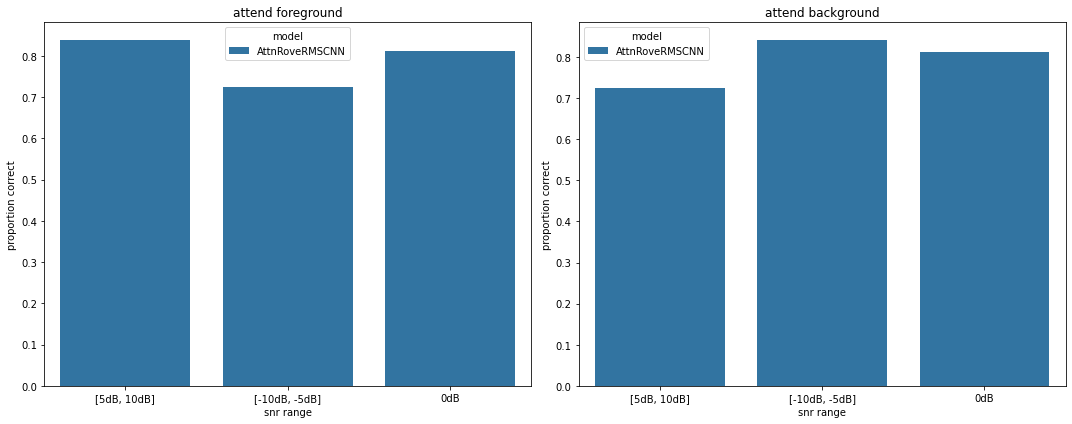

In [19]:
fig, axs = plt.subplots (1, 2, figsize=(15, 6))


g = sn.barplot(
    data=rms_results, x='snr_condition',y='ACC/test_fg_acc', hue='model',
    ci=None, seed=1, ax=axs[0]
)
axs[0].set(xlabel="snr range", ylabel='proportion correct', title='attend foreground')
g.set_xticklabels(['[5dB, 10dB]', '[-10dB, -5dB]', '0dB'])

h = sn.barplot(
    data=rms_results, x='snr_condition',y='ACC/test_bg_acc', hue='model',
    ci=None, seed=1, ax=axs[1]
)
axs[1].set(xlabel="snr range", ylabel='proportion correct', title='attend background')
h.set_xticklabels(['[5dB, 10dB]', '[-10dB, -5dB]', '0dB'])

plt.tight_layout()

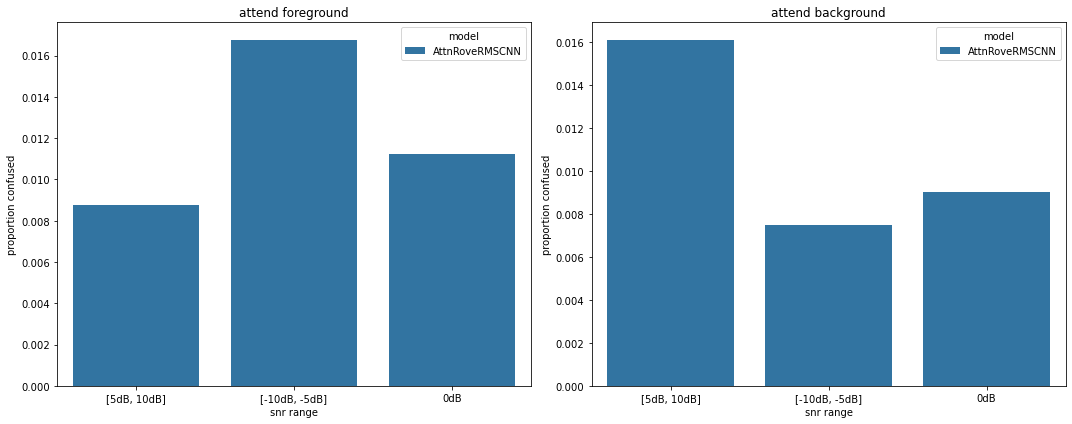

In [20]:
fig, axs = plt.subplots (1, 2, figsize=(15, 6))


g = sn.barplot(
    data=rms_results, x='snr_condition',y='fg_confusion', hue='model',
    ci=None, seed=1, ax=axs[0]
)
axs[0].set(xlabel="snr range", ylabel='proportion confused', title='attend foreground')
g.set_xticklabels(['[5dB, 10dB]', '[-10dB, -5dB]', '0dB'])

h = sn.barplot(
    data=rms_results, x='snr_condition',y='bg_confusion', hue='model',
    ci=None, seed=1, ax=axs[1]
)
axs[1].set(xlabel="snr range", ylabel='proportion confused', title='attend background')
h.set_xticklabels(['[5dB, 10dB]', '[-10dB, -5dB]', '0dB'])

plt.tight_layout()

In [21]:
#get the subset of datapoints where the model fails
fg_confusion_results = rms_results[rms_results['ACC/test_fg_acc'] == 0]
bg_confusion_results = rms_results[rms_results['ACC/test_bg_acc'] == 0]
both_confusion_results = fg_confusion_results[fg_confusion_results['ACC/test_bg_acc'] == 0]

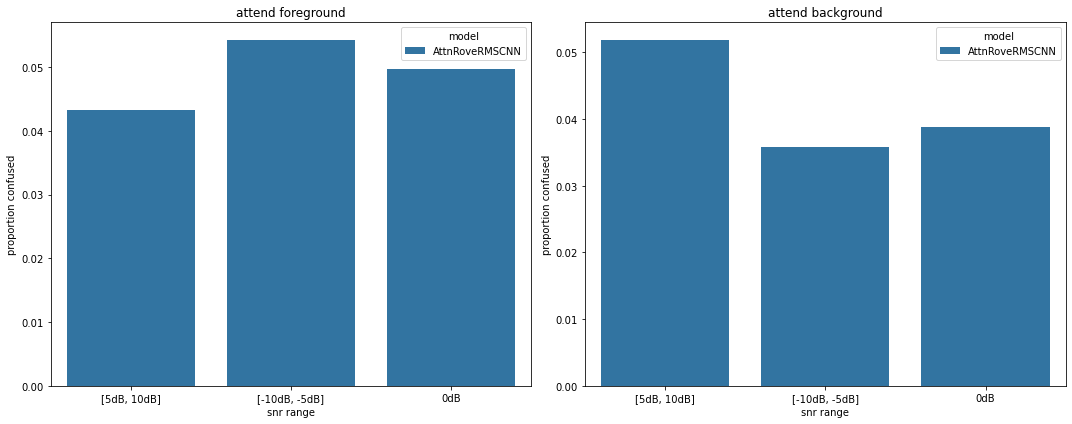

In [22]:
fig, axs = plt.subplots (1, 2, figsize=(15, 6))


g = sn.barplot(
    data=fg_confusion_results, x='snr_condition',y='fg_confusion', hue='model',
    ci=None, seed=1, ax=axs[0]
)
axs[0].set(xlabel="snr range", ylabel='proportion confused', title='attend foreground')
g.set_xticklabels(['[5dB, 10dB]', '[-10dB, -5dB]', '0dB'])

h = sn.barplot(
    data=bg_confusion_results, x='snr_condition',y='bg_confusion', hue='model',
    ci=None, seed=1, ax=axs[1]
)
axs[1].set(xlabel="snr range", ylabel='proportion confused', title='attend background')
h.set_xticklabels(['[5dB, 10dB]', '[-10dB, -5dB]', '0dB'])

plt.tight_layout()

## Combining the Results

In [23]:
filtered_results.rename(columns={"ACC/test_fg_acc_step": "ACC/test_fg_acc", "ACC/test_bg_acc_step": "ACC/test_bg_acc" }, inplace=True)
filtered_results
combined_results = pd.concat([rms_results, filtered_results], axis=0, ignore_index=True)
combined_results['attended accuracy'] = (combined_results['ACC/test_fg_acc'] + combined_results['ACC/test_bg_acc'])/2
combined_results

,ACC/test_fg_acc,fg_confusion,ACC/test_bg_acc,bg_confusion,step,model,snr_condition,version,attended accuracy
0,1.0,0.0,1.0,0.0,0,AttnRoveRMSCNN,high,version_1,1.0
1,1.0,0.0,1.0,0.0,1,AttnRoveRMSCNN,high,version_1,1.0
2,0.0,0.0,1.0,0.0,2,AttnRoveRMSCNN,high,version_1,0.5
3,1.0,0.0,0.0,0.0,3,AttnRoveRMSCNN,high,version_1,0.5
4,1.0,0.0,0.0,0.0,4,AttnRoveRMSCNN,high,version_1,0.5
...,...,...,...,...,...,...,...,...,...
142609,1.0,NaN,1.0,NaN,13235,AttnCNN,neutral,version_2,1.0
142610,1.0,NaN,1.0,NaN,13236,AttnCNN,neutral,version_2,1.0
142611,1.0,NaN,1.0,NaN,13237,AttnCNN,neutral,version_2,1.0
142612,0.0,NaN,1.0,NaN,13238,AttnCNN,neutral,version_2,0.5


In [24]:
test = combined_results.groupby(['model', 'snr_condition']).mean()
test

ACC/test_fg_acc  fg_confusion  \
model               snr_condition                                  
AttnCNN             high                  0.836616           NaN   
                    low                   0.726744           NaN   
                    neutral               0.809743           NaN   
AttnRoveRMSCNN      high                  0.839341      0.008744   
                    low                   0.723947      0.016774   
                    neutral               0.810909      0.011242   
AttnTrackingControl high                  0.322151           NaN   
                    low                   0.108137           NaN   
                    neutral               0.206162           NaN   

                                   ACC/test_bg_acc  bg_confusion         step  \
model               snr_condition                                               
AttnCNN             high                  0.721860           NaN  6600.500000   
                    low                   0.841015           NaN  7648.000000   
                    neutral               0.812915           NaN  6619.500000   
AttnRoveRMSCNN      high                  0.723888      0.016119  8405.500000   
                    low                   0.842434      0.007495  8405.500000   
                    neutral               0.813050      0.009041  8405.500000   
AttnTrackingControl high                  0.107721           NaN  8405.000059   
                    low                   0.327385           NaN  8405.000059   
                    neutral               0.210861           NaN  8405.000059   

                                   attended accuracy  
model               snr_condition                     
AttnCNN             high                    0.779238  
                    low                     0.783879  
                    neutral                 0.811329  
AttnRoveRMSCNN      high                    0.781614  
                    low                     0.783191  
                    neutral                 0.811980  
AttnTrackingControl high                    0.214936  
                    low                     0.217761  
                    neutral                 0.208512

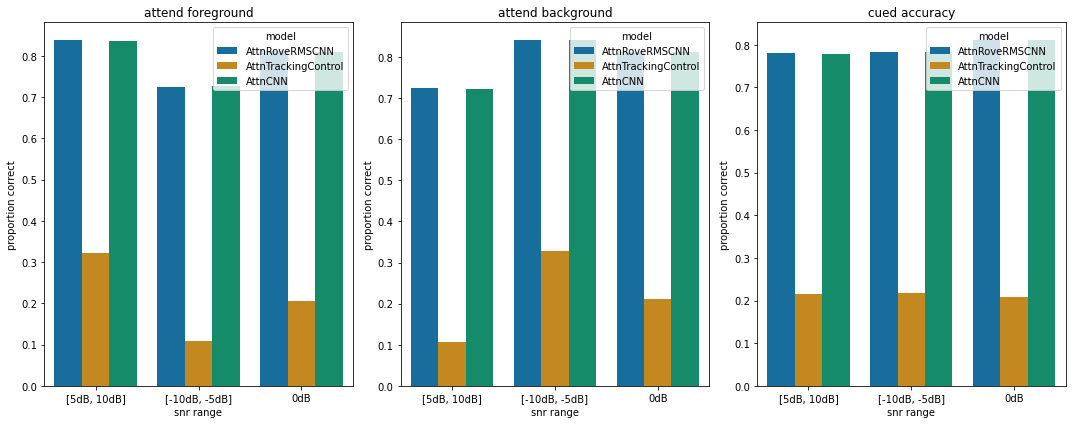

In [25]:
fig, axs = plt.subplots (1, 3, figsize=(15, 6))


g = sn.barplot(
    data=combined_results, x='snr_condition',y='ACC/test_fg_acc', hue='model',
    ci=None, seed=1, ax=axs[0], palette='colorblind'
)
axs[0].set(xlabel="snr range", ylabel='proportion correct', title='attend foreground')
g.set_xticklabels(['[5dB, 10dB]', '[-10dB, -5dB]', '0dB'])

h = sn.barplot(
    data=combined_results, x='snr_condition',y='ACC/test_bg_acc', hue='model',
    ci=None, seed=1, ax=axs[1], palette='colorblind'
)
axs[1].set(xlabel="snr range", ylabel='proportion correct', title='attend background')
h.set_xticklabels(['[5dB, 10dB]', '[-10dB, -5dB]', '0dB'])

i = sn.barplot(
    data=combined_results, x='snr_condition',y='attended accuracy', hue='model',
    ci=None, seed=1, ax=axs[2], palette='colorblind'
)
axs[2].set(xlabel="snr range", ylabel='proportion correct', title='cued accuracy')
i.set_xticklabels(['[5dB, 10dB]', '[-10dB, -5dB]', '0dB'])

plt.tight_layout()

In [26]:
#snr condition, then check if the lower db word was guessed
#neutral condition, check if it gets either

In [29]:
control_confusion_results = combined_results[combined_results['model'] == "AttnTrackingControl"]
print(control_confusion_results.shape)
control_confusion_results['ctrl_confusion'] = '0'


control_confusion_results.loc[control_confusion_results['snr_condition']=='high', 'ctrl_confusion'] = control_confusion_results['ACC/test_bg_acc']
control_confusion_results.loc[control_confusion_results['snr_condition']=='low', 'ctrl_confusion'] = control_confusion_results['ACC/test_fg_acc']
control_confusion_results.loc[control_confusion_results['snr_condition']=='neutral', 'ctrl_confusion'] = control_confusion_results['ACC/test_fg_acc']

#if it got either word right, ie an attended accuracy of 0.5 or 1, then
#set the control confusion to 1 because it got at least 1 right
control_confusion_results.loc[control_confusion_results['ctrl_confusion'] > 0.1, 'ctrl_confusion'] = 1.0

# control_confusion_results
#print(control_confusion_results[control_confusion_results['snr_condition'] == 'high'])
subset = control_confusion_results[pd.isna(control_confusion_results['ACC/test_fg_acc'])]
#subset
#subset.filter()

control_confusion_results.drop([67248, 84061, 100874], axis=0, inplace=True)
#control_confusion_results

control_confusion_results['control_listening_condition'] = "low"
louder_word_rec = control_confusion_results.copy(deep=True)
louder_word_rec['control_listening_condition'] = "high"

louder_word_rec.loc[louder_word_rec['snr_condition']=='high', 'ctrl_confusion'] = louder_word_rec['ACC/test_fg_acc']
louder_word_rec.loc[louder_word_rec['snr_condition']=='low', 'ctrl_confusion'] = louder_word_rec['ACC/test_bg_acc']
louder_word_rec.loc[louder_word_rec['snr_condition']=='neutral', 'ctrl_confusion'] = louder_word_rec['ACC/test_bg_acc']

#if it got either word right, ie an attended accuracy of 0.5 or 1, then
#set the control confusion to 1 because it got at least 1 right
louder_word_rec.loc[louder_word_rec['ctrl_confusion'] > 0.1, 'ctrl_confusion'] = 1.0

combined_confusion_results = pd.concat([control_confusion_results, louder_word_rec], axis=0)
combined_confusion_results

(50439, 9)


/tmp/ipykernel_118147/3787550748.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  control_confusion_results['ctrl_confusion'] = '0'
/tmp/ipykernel_118147/3787550748.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  control_confusion_results.drop([67248, 84061, 100874], axis=0, inplace=True)
/tmp/ipykernel_118147/3787550748.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable

,ACC/test_fg_acc,fg_confusion,ACC/test_bg_acc,bg_confusion,step,model,snr_condition,version,attended accuracy,ctrl_confusion,control_listening_condition
50436,0.0,NaN,1.0,NaN,0,AttnTrackingControl,high,version_0,0.5,1.0,low
50437,1.0,NaN,0.0,NaN,1,AttnTrackingControl,high,version_0,0.5,0.0,low
50438,1.0,NaN,0.0,NaN,2,AttnTrackingControl,high,version_0,0.5,0.0,low
50439,1.0,NaN,0.0,NaN,3,AttnTrackingControl,high,version_0,0.5,0.0,low
50440,1.0,NaN,0.0,NaN,4,AttnTrackingControl,high,version_0,0.5,0.0,low
...,...,...,...,...,...,...,...,...,...,...,...
100869,0.0,NaN,1.0,NaN,16807,AttnTrackingControl,neutral,version_0,0.5,1.0,high
100870,1.0,NaN,0.0,NaN,16808,AttnTrackingControl,neutral,version_0,0.5,0.0,high
100871,0.0,NaN,0.0,NaN,16809,AttnTrackingControl,neutral,version_0,0.0,0.0,high
100872,1.0,NaN,0.0,NaN,16810,AttnTrackingControl,neutral,version_0,0.5,0.0,high


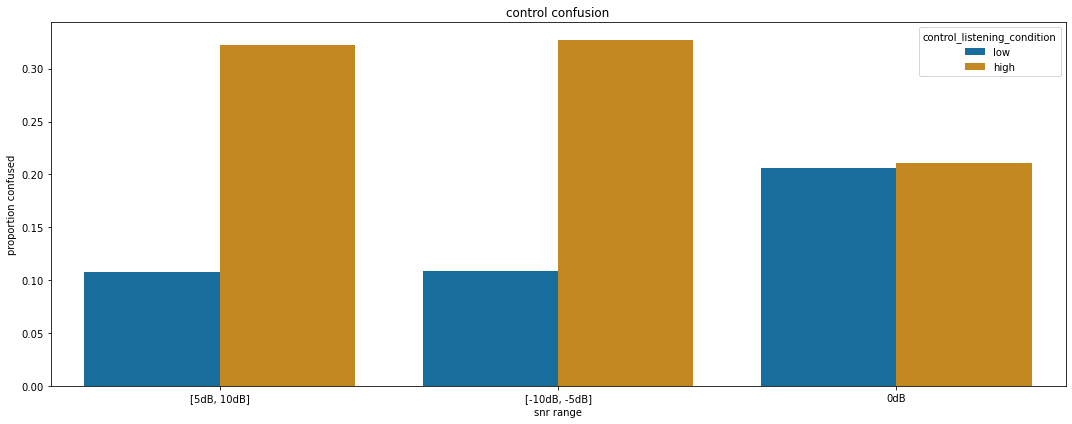

In [30]:
fig, axs = plt.subplots (1, 1, figsize=(15, 6))

g = sn.barplot(
    data=combined_confusion_results, x='snr_condition',y='ctrl_confusion', hue='control_listening_condition',
    ci=None, seed=1, ax=axs, palette='colorblind'
)
axs.set(xlabel="snr range", ylabel='proportion confused', title='control confusion')
g.set_xticklabels(['[5dB, 10dB]', '[-10dB, -5dB]', '0dB'])


plt.tight_layout()